# Capstone 2: Business Analysis with Python

### EmporiUm: Student Bookstore Chain Sales Analysis

This capstone project is about the analysis of sales in Connecticut and New York of the East Region. Utilizing python and multiple python libraries like: NumPy, pandas, and Matplotlib.

- **Region:** East
    - **Territory:** Connecticut
        - **Manager:** Ana Jilani
        - **StoreID:** 865 - 872
    - **Territory:** New York
        - **Manager:** Ana Jilani
        - **StoreID:** 840 - 851

The analysis includes:

- Monthly total revenue trend
- Ranking of store performances
- Customer purchasing behavior
- Product category analysis
- Next quarter marketing recommendation

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Import files

In [2]:
cust_list = pd.read_csv('customer_list.csv')

In [3]:
cust_list.head()

,cust_id|date|time|name|email|phone|sms-opt-out
0,1|2023-03-15|08:45:12|Rachel|rachel@centralper...
1,2|2023-05-22|12:30:45|R. Geller|rossg@centralp...
2,3|2023-07-09|18:15:27|Monica Geller|chefmonica...
3,4|2023-09-01|21:05:33|Chandler Bing|chandlerb@...
4,5|2023-11-18|14:22:10|Joey|howyoudoing@central...


In [4]:
cust_list.info()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 1 columns):
 #   Column                                           Non-Null Count  Dtype
---  ------                                           --------------  -----
 0   cust_id|date|time|name|email|phone|sms-opt-out   521 non-null    str  
dtypes: str(1)
memory usage: 4.2 KB


In [5]:
prod_categories = pd.read_csv('ProductCategories.csv')

In [6]:
prod_categories.head()

,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [7]:
prod_categories.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


In [8]:
products = pd.read_csv('Products.csv')

In [9]:
products.head()

,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [10]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


In [11]:
store_detail = pd.read_csv('StoreDetail.csv')

In [12]:
store_detail.head()

,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [13]:
store_detail.info()

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


In [14]:
store_sales = pd.read_csv('StoreSales.csv')

In [15]:
store_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [16]:
store_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


## Core Marketing Analysis

**Who are the territory managers for the sales territories assigned? What are the store IDs and cities for the stores in each assigned sales territory?**

In [17]:
ct_info = store_detail[store_detail['State'] == 'Connecticut']
ct_id = ct_info["Store ID"].tolist()  # created a variable to store all Store IDs within Connecticut.
                                      # In the case, my manager adds in another store.
ct_info
# Connecticut: 865-872, Ellen Lemon

,Store Location,State,Store ID,Territory Manager,Region,Region Director
18,Bridgeport,Connecticut,865,Ellen Lemon,East,Ana Jilani
19,Darien,Connecticut,866,Ellen Lemon,East,Ana Jilani
20,Hartford,Connecticut,867,Ellen Lemon,East,Ana Jilani
21,Litchfield County,Connecticut,868,Ellen Lemon,East,Ana Jilani
22,New Haven,Connecticut,869,Ellen Lemon,East,Ana Jilani
23,New London,Connecticut,870,Ellen Lemon,East,Ana Jilani
24,Old Saybrook,Connecticut,871,Ellen Lemon,East,Ana Jilani
25,Waterbury,Connecticut,872,Ellen Lemon,East,Ana Jilani


In [18]:
ny_info = store_detail[store_detail['State'] == 'New York']
ny_id = ny_info['Store ID'].tolist()
ny_info
# New York: 840-851, See Ellefson

,Store Location,State,Store ID,Territory Manager,Region,Region Director
86,Albany,New York,840,See Ellefson,East,Ana Jilani
87,Buffalo,New York,841,See Ellefson,East,Ana Jilani
88,Elmira,New York,842,See Ellefson,East,Ana Jilani
89,Ithaca,New York,843,See Ellefson,East,Ana Jilani
90,Oswego,New York,844,See Ellefson,East,Ana Jilani
91,Plattsburgh,New York,845,See Ellefson,East,Ana Jilani
92,Poestenkill,New York,846,See Ellefson,East,Ana Jilani
93,Rochester,New York,847,See Ellefson,East,Ana Jilani
94,Syracuse,New York,848,See Ellefson,East,Ana Jilani
95,Brooklyn,New York,849,See Ellefson,East,Ana Jilani


**What is monthly total revenue for in-store sales in each of the two sales territories, over the full period covered by the data?**

In [19]:
# Finding Connecticut's monthly total revenue
ct_sales = store_sales[store_sales['Store ID'].isin(ct_id)]
ct_sales

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
130,1/1/2022,865,NaN,105370-S,8.45
131,1/1/2022,867,NaN,105330-IT,1376.44
132,1/1/2022,867,NaN,105371-T,216.90
133,1/1/2022,870,NaN,105372-S,7.85
134,1/1/2022,871,NaN,105373-T,88.42
...,...,...,...,...,...
335089,12/31/2025,871,NaN,105727-M,50.96
335090,12/31/2025,871,307.0,105429-T,71.80
335091,12/31/2025,871,NaN,105325-IT,1717.70
335092,12/31/2025,871,NaN,105278-IT,272.24


In [20]:
# Convert Transaction date to datetime
ct_sales["Transaction Date"] = pd.to_datetime(ct_sales["Transaction Date"]) # Currently, "Transaction Date" is a str type, we want to convert it to datetime to manipulate it
ct_sales["Date"] = ct_sales["Transaction Date"].dt.to_period("M")


In [21]:
# Connecticut's Monthly revenue from 2022-2025
ct_monthly_revenue = ct_sales.groupby("Date")[["Sale Amount"]].sum()
ct_monthly_revenue

,Sale Amount
Date,
2022-01,29958.25
2022-02,25563.98
2022-03,33995.57
2022-04,31587.12
2022-05,37953.48
2022-06,32008.85
2022-07,30656.27
2022-08,42881.99
2022-09,30369.64


In [22]:
# Finding New York's monthly total revenue
ny_sales = store_sales[store_sales["Store ID"].isin(ny_id)]
ny_sales

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
117,1/1/2022,840,NaN,105315-IT,34.43
118,1/1/2022,842,NaN,105346-IT,318.96
119,1/1/2022,843,47.0,105349-M,8.00
120,1/1/2022,844,NaN,105446-B,12.70
121,1/1/2022,845,NaN,105447-M,50.96
...,...,...,...,...,...
335069,12/31/2025,850,NaN,105376-M,44.50
335070,12/31/2025,850,427.0,105608-A,12.15
335071,12/31/2025,851,NaN,105812-B,25.45
335072,12/31/2025,851,NaN,105760-S,7.85


In [23]:
# Convert Transaction date to datetime
ny_sales["Transaction Date"] = pd.to_datetime(ny_sales["Transaction Date"]) 
ny_sales["Date"] = ny_sales["Transaction Date"].dt.to_period("M")


In [24]:
# New York's Monthly revenue from 2022-2025
ny_monthly_revenue = ny_sales.groupby("Date")[["Sale Amount"]].sum()
ny_monthly_revenue

,Sale Amount
Date,
2022-01,58635.53
2022-02,60262.97
2022-03,57143.40
2022-04,56880.02
2022-05,51805.22
2022-06,60549.86
2022-07,56250.74
2022-08,55052.53
2022-09,60495.63


**How would you rank the sales performance of each store in each sales territory? Which are the top-performing stores?**

In [25]:
# Ranking on stores in Connecticut
ct_rank = ct_sales.groupby("Store ID")[["Sale Amount"]].sum()

In [26]:
ct_rank = ct_rank.sort_values("Sale Amount", ascending=False)
ct_rank = ct_rank.merge(ct_info[["Store ID", "Store Location"]], on="Store ID") # merged the 2 DF, to add in store location column
ct_rank

,Store ID,Sale Amount,Store Location
0,870,331116.76,New London
1,865,322100.07,Bridgeport
2,867,309592.06,Hartford
3,872,295651.17,Waterbury
4,869,286779.43,New Haven
5,868,286217.15,Litchfield County
6,866,283455.62,Darien
7,871,277310.18,Old Saybrook


In [27]:
ny_rank = ny_sales.groupby("Store ID")[["Sale Amount"]].sum()

In [28]:
ny_rank = ny_rank.sort_values("Sale Amount", ascending=False)
ny_rank = ny_rank.merge(ny_info[["Store ID", "Store Location"]], on="Store ID")
ny_rank

,Store ID,Sale Amount,Store Location
0,850,621565.02,New York
1,847,607148.21,Rochester
2,846,334175.88,Poestenkill
3,841,314979.99,Buffalo
4,842,313971.65,Elmira
5,843,313920.05,Ithaca
6,845,311520.52,Plattsburgh
7,840,310389.02,Albany
8,848,306998.14,Syracuse
9,849,304732.76,Brooklyn


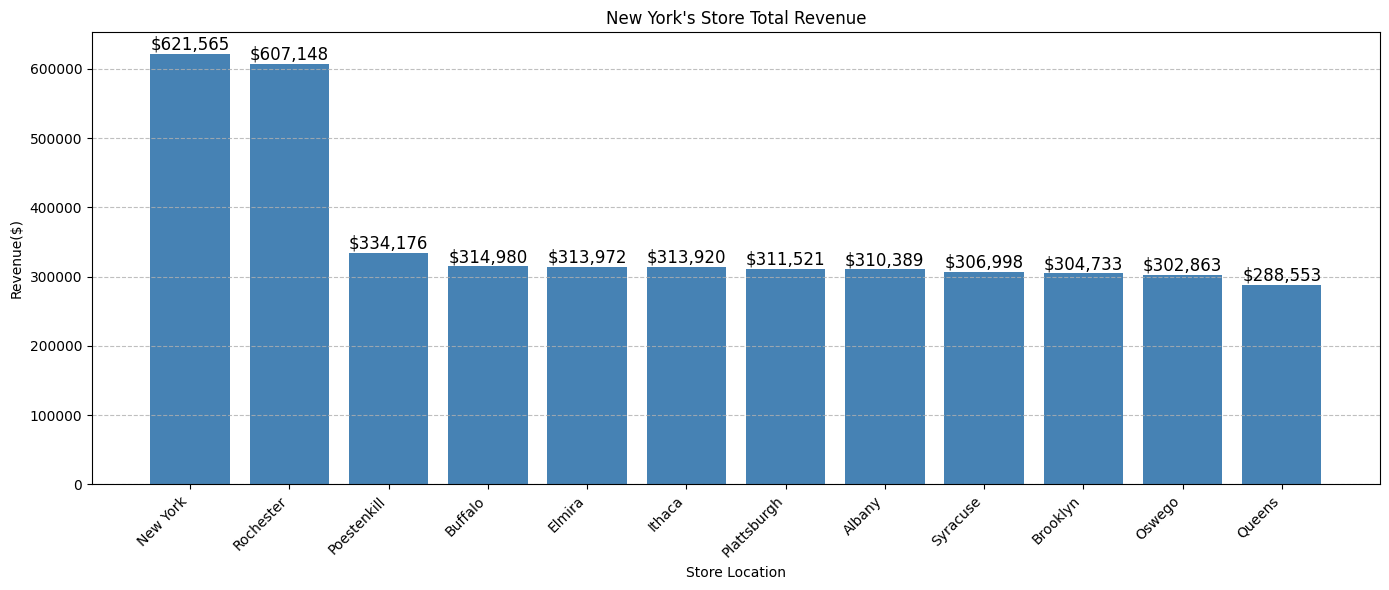

In [61]:
# Bar Chart for New York's store total revenue
plt.figure(figsize=(14,6))
bars = plt.bar(ny_rank["Store Location"], ny_rank["Sale Amount"], color="steelblue")
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"${bar.get_height():,.0f}",
             ha="center", va="bottom", fontsize=12)
plt.title("New York's Store Total Revenue")
plt.xlabel("Store Location")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Revenue($)")
plt.grid(axis="y", linestyle="--", alpha=0.8)
plt.tight_layout()
plt.show()

**Comparing the customer ID from the customer list data with the rewards ID from the sales data, who were the top customers in each sales territory?**

In [29]:
# Connecticut first
# "customer_list.csv" uses "|" so need to load correctly
cust_list = pd.read_csv("customer_list.csv", sep="|")
cust_list.head() # verify it works

,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


In [30]:
# Now need to remove the NaN values in the RewardID column
ct_cust = ct_sales[ct_sales["RewardsID"].notna()] # only keep rows, that has a RewardID

print(ct_sales.shape)
print(ct_cust.shape)

(17378, 6)
(1848, 6)


In [31]:
# Now merge 
ct_cust_sales = ct_cust.merge(cust_list, left_on="RewardsID", right_on="cust_id")
ct_cust_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Date,cust_id,date,time,name,email,phone,sms-opt-out
0,2022-01-02,868,441.0,105478-B,17.70,2022-01,441,2023-04-28,13:15:05,Uncle Leo,hello@vandelayindustries.com,212-555-2410,N
1,2022-01-02,872,231.0,105481-T,74.50,2022-01,231,2023-09-18,12:35:40,Maria LaGuerta,maria@miamimetro.gov,305-555-1606,N
2,2022-01-03,867,416.0,105548-M,6.00,2022-01,416,2023-11-05,06:00:55,Grover,grover@sesamestreet.org,212-555-2205,N
3,2022-01-05,865,3.0,105664-A,12.12,2022-01,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
4,2022-01-07,867,95.0,105384-A,23.44,2022-01,95,2024-04-05,11:25:35,Leo Markus,leo@willandgrace.nyc,212-555-9210,N


In [32]:
ct_cust_sales = ct_cust_sales[["RewardsID", "name", "Sale Amount"]] # cleaned up the columns I needed and did not need
ct_cust_sales

,RewardsID,name,Sale Amount
0,441.0,Uncle Leo,17.70
1,231.0,Maria LaGuerta,74.50
2,416.0,Grover,6.00
3,3.0,Monica Geller,12.12
4,95.0,Leo Markus,23.44
...,...,...,...
1843,50.0,Creed,17.70
1844,311.0,Dawn Summers,134.80
1845,165.0,Ken Franklin,19.36
1846,57.0,Ron Swanson,61.14


In [33]:
# now to find the best customer in Connecticut
ct_cust_sales = ct_cust_sales.groupby(["RewardsID", "name"])[["Sale Amount"]].sum().sort_values("Sale Amount", ascending=False)
ct_cust_sales.head()

# Marie S. is the top customer in Connecticut with $4388.87

,,Sale Amount
RewardsID,name,
18.0,Marie S.,4388.87
21.0,Jon Snow,3676.21
322.0,Fox Mulder,3569.60
365.0,Pugsley A.,3009.29
104.0,Helen M.,2886.72


In [34]:
# New York's Best Customer
# Only want customers thaty have a RewardsID
ny_cust = ny_sales[ny_sales["RewardsID"].notna()]

In [35]:
# merging DataFrames
ny_cust_sales = ny_cust.merge(cust_list, left_on="RewardsID", right_on="cust_id")
ny_cust_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Date,cust_id,date,time,name,email,phone,sms-opt-out
0,2022-01-01,843,47.0,105349-M,8.00,2022-01,47,2024-04-01,15:05:45,Stanley H.,stanley@dundermifflin.com,570-555-5007,N
1,2022-01-02,848,139.0,105356-S,13.13,2022-01,139,2023-06-10,20:55:10,Ashley A.,ashley@genoa.city,213-555-9704,N
2,2022-01-03,842,375.0,105608-A,12.15,2022-01,375,2023-08-21,21:35:30,C.J. Cregg,cj@westwing.gov,202-555-1804,Y
3,2022-01-04,841,47.0,105626-S,6.02,2022-01,47,2024-04-01,15:05:45,Stanley H.,stanley@dundermifflin.com,570-555-5007,N
4,2022-01-05,841,325.0,105546-T,212.32,2022-01,325,2024-01-31,22:40:00,Cigarette Smoking Man,csm@fbi.gov,202-555-1304,Y


In [36]:
ny_cust_sales = ny_cust_sales.groupby(["RewardsID", "name"])[["Sale Amount"]].sum().sort_values("Sale Amount", ascending=False)
ny_cust_sales.head()

# Julian Bashir is the top customer in New York with $6039.32

,,Sale Amount
RewardsID,name,
300.0,Julian Bashir,6039.32
129.0,Jason Morgan,3918.72
188.0,Mellie Grant,3805.61
483.0,Peggy Olson,3504.20
199.0,Gonzo,3441.19


**What is the number of transactions per month by product category in each assigned territory?**

In [37]:
# Need to connect ct_sales to ProductCategories
ct_prod_sales = ct_sales.merge(products, on="Prod Num") # merges ct_sales with products

ct_prod_sales = ct_prod_sales.merge(prod_categories, on="SubcategoryID") # The merge: ct_sales --> products --> Product Categories
ct_prod_sales = ct_prod_sales.merge(store_detail, on="Store ID")
ct_prod_sales

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Date,Product,CategoryID_x,SubcategoryID,CategoryID_y,Category,Subcategory,Store Location,State,Territory Manager,Region,Region Director
0,2022-01-01,865,NaN,105370-S,8.45,2022-01,Pilot Precise V5 RT Rollerball Pens (Black),110,110-wri,110,Stationery and Supplies,Writing Instruments,Bridgeport,Connecticut,Ellen Lemon,East,Ana Jilani
1,2022-01-01,867,NaN,105330-IT,1376.44,2022-01,LG Gram 17,120,120-lap,120,Technology & Accessories,Laptops,Hartford,Connecticut,Ellen Lemon,East,Ana Jilani
2,2022-01-01,867,NaN,105371-T,216.90,2022-01,Political Science: Theory and Practice,100,100-soc,100,Textbooks,Social Sciences,Hartford,Connecticut,Ellen Lemon,East,Ana Jilani
3,2022-01-01,870,NaN,105372-S,7.85,2022-01,Paper Cutter Trimmer (Letter Size),110,110-des,110,Stationery and Supplies,Desk Accessories,New London,Connecticut,Ellen Lemon,East,Ana Jilani
4,2022-01-01,871,NaN,105373-T,88.42,2022-01,English as a Second Language,100,100-lan,100,Textbooks,Language and Linguistics,Old Saybrook,Connecticut,Ellen Lemon,East,Ana Jilani
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18028,2025-12-31,871,NaN,105727-M,50.96,2025-12,LTCA Year Up Quarter-Zip Sweatshirt (Maroon),130,130-clo,130,Apparel and Merchandise,"Clothing (T-Shirts, Hoodies, and Jackets)",Old Saybrook,Connecticut,Ellen Lemon,East,Ana Jilani
18029,2025-12-31,871,307.0,105429-T,71.80,2025-12,MCAT Biology and Biochemistry,100,100-exa,100,Textbooks,Exam Prep and Study Guides,Old Saybrook,Connecticut,Ellen Lemon,East,Ana Jilani
18030,2025-12-31,871,NaN,105325-IT,1717.70,2025-12,"Apple MacBook Pro (M2, 14-inch)",120,120-lap,120,Technology & Accessories,Laptops,Old Saybrook,Connecticut,Ellen Lemon,East,Ana Jilani
18031,2025-12-31,871,NaN,105278-IT,272.24,2025-12,Tableau Desktop,120,120-sof,120,Technology & Accessories,Software Download,Old Saybrook,Connecticut,Ellen Lemon,East,Ana Jilani


In [38]:
# Converting column "Transaction Date" to datetime
ct_prod_sales["Transaction Date"] = pd.to_datetime(ct_prod_sales["Transaction Date"]) 
ct_prod_sales["Date"] = ct_prod_sales["Transaction Date"].dt.to_period("M")

In [39]:
ct_transactions = ct_prod_sales.groupby(["State","Date", "Category"]).size()
ct_transactions # this is a Series

State        Date     Category                
Connecticut  2022-01  Apparel and Merchandise      42
                      Art Supplies                 32
                      Books (General)              19
                      Stationery and Supplies      38
                      Technology & Accessories     45
                                                 ... 
             2025-12  Art Supplies                101
                      Books (General)              40
                      Stationery and Supplies     114
                      Technology & Accessories    132
                      Textbooks                    55
Length: 288, dtype: int64

In [40]:
# Make it into a DataFrame
ct_transactions = ct_transactions.reset_index()
ct_transactions.columns = ["State", "Date", "Category", "Transaction Count"]
ct_transactions

,State,Date,Category,Transaction Count
0,Connecticut,2022-01,Apparel and Merchandise,42
1,Connecticut,2022-01,Art Supplies,32
2,Connecticut,2022-01,Books (General),19
3,Connecticut,2022-01,Stationery and Supplies,38
4,Connecticut,2022-01,Technology & Accessories,45
...,...,...,...,...
283,Connecticut,2025-12,Art Supplies,101
284,Connecticut,2025-12,Books (General),40
285,Connecticut,2025-12,Stationery and Supplies,114
286,Connecticut,2025-12,Technology & Accessories,132


In [41]:
# Total number of transaction by product category in New York
ny_prod_sales = ny_sales.merge(products, on="Prod Num")

ny_prod_sales = ny_prod_sales.merge(prod_categories, on="SubcategoryID").merge(store_detail, on="Store ID")
ny_prod_sales

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Date,Product,CategoryID_x,SubcategoryID,CategoryID_y,Category,Subcategory,Store Location,State,Territory Manager,Region,Region Director
0,2022-01-01,840,NaN,105315-IT,34.43,2022-01,UGREEN Nexode 140W USB-C Charger,120,120-cha,120,Technology & Accessories,Chargers and Power Adapters,Albany,New York,See Ellefson,East,Ana Jilani
1,2022-01-01,842,NaN,105346-IT,318.96,2022-01,R Studio Desktop,120,120-sof,120,Technology & Accessories,Software Download,Elmira,New York,See Ellefson,East,Ana Jilani
2,2022-01-01,843,47.0,105349-M,8.00,2022-01,LTCA Year Up Gel Pen (Pack of 2),130,130-off,130,Apparel and Merchandise,Office and Study Supplies,Ithaca,New York,See Ellefson,East,Ana Jilani
3,2022-01-01,844,NaN,105446-B,12.70,2022-01,The Omnivores Dilemma,125,125-non,125,Books (General),Non-Fiction,Oswego,New York,See Ellefson,East,Ana Jilani
4,2022-01-01,845,NaN,105447-M,50.96,2022-01,LTCA Year Up Bomber Jacket (Black),130,130-clo,130,Apparel and Merchandise,"Clothing (T-Shirts, Hoodies, and Jackets)",Plattsburgh,New York,See Ellefson,East,Ana Jilani
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32206,2025-12-31,850,NaN,105376-M,44.50,2025-12,LTCA Year Up Fleece Blanket (Gray),130,130-hom,130,Apparel and Merchandise,Home and Decor,New York,New York,See Ellefson,East,Ana Jilani
32207,2025-12-31,850,427.0,105608-A,12.15,2025-12,Olfa Rotary Cutter (45mm),115,115-cut,115,Art Supplies,Cutting and Measuring Tools,New York,New York,See Ellefson,East,Ana Jilani
32208,2025-12-31,851,NaN,105812-B,25.45,2025-12,Big Little Lies,125,125-fic,125,Books (General),Fiction,Queens,New York,See Ellefson,East,Ana Jilani
32209,2025-12-31,851,NaN,105760-S,7.85,2025-12,Fellowes Mesh Desk Organizer,110,110-des,110,Stationery and Supplies,Desk Accessories,Queens,New York,See Ellefson,East,Ana Jilani


In [42]:
ny_prod_sales["Transaction Date"] = pd.to_datetime(ny_prod_sales["Transaction Date"])
ny_prod_sales["Date"] = ny_prod_sales["Transaction Date"].dt.to_period("M")

In [63]:
ny_transactions = ny_prod_sales.groupby(["Date", "Category"]).size() # This will count each valid row
ny_transactions

Date     Category                
2022-01  Apparel and Merchandise      66
         Art Supplies                 61
         Books (General)              24
         Stationery and Supplies      76
         Technology & Accessories     73
                                    ... 
2025-12  Art Supplies                151
         Books (General)              76
         Stationery and Supplies     202
         Technology & Accessories    228
         Textbooks                    97
Length: 288, dtype: int64

In [64]:
# Convert ny_transaction to a DataFrame
ny_transactions = ny_transactions.reset_index() # turns the labels into columns
ny_transactions.columns = ["Date", "Category", "Transaction Count"]
ny_transactions

,Date,Category,Transaction Count
0,2022-01,Apparel and Merchandise,66
1,2022-01,Art Supplies,61
2,2022-01,Books (General),24
3,2022-01,Stationery and Supplies,76
4,2022-01,Technology & Accessories,73
...,...,...,...
283,2025-12,Art Supplies,151
284,2025-12,Books (General),76
285,2025-12,Stationery and Supplies,202
286,2025-12,Technology & Accessories,228


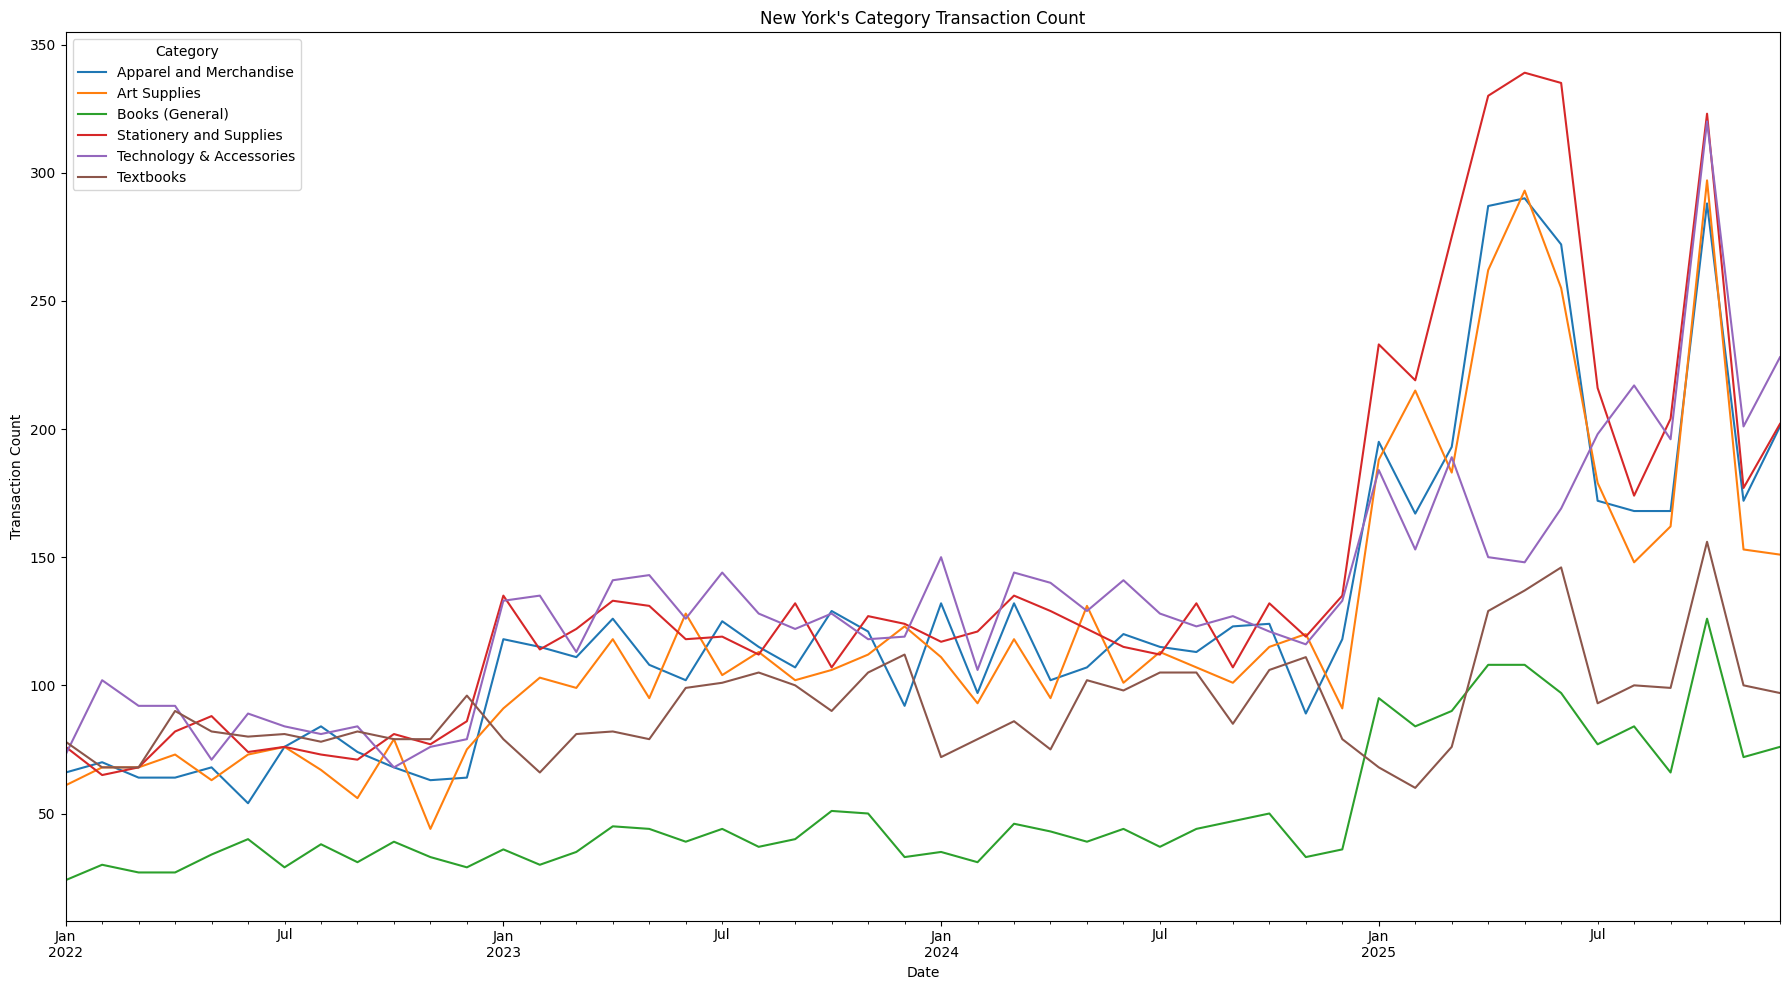

In [69]:
# Line chart for New York's category transaction count over a period of time
ny_CatCount = ny_transactions.pivot(index="Date", columns="Category", values="Transaction Count")
ny_CatCount.plot(kind="line", figsize=(18,10))
plt.title("New York's Category Transaction Count")
plt.xlabel("Date")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.show()


**What is total sales revenue per month by category?**

In [45]:
# Total sales revenue per month by category for Connecticut
ct_prod_revenue = ct_prod_sales.groupby(["State", "Date", "Category"])["Sale Amount"].sum()
ct_prod_revenue

State        Date     Category                
Connecticut  2022-01  Apparel and Merchandise      1223.25
                      Art Supplies                  725.36
                      Books (General)               489.60
                      Stationery and Supplies       387.34
                      Technology & Accessories    21860.06
                                                    ...   
             2025-12  Art Supplies                 3300.96
                      Books (General)              1399.52
                      Stationery and Supplies      1396.21
                      Technology & Accessories    74810.44
                      Textbooks                    8793.17
Name: Sale Amount, Length: 288, dtype: float64

In [46]:
ct_prod_revenue = ct_prod_revenue.reset_index()
ct_prod_revenue.columns = ["State", "Date", "Category", "Total Revenue"]
ct_prod_revenue

,State,Date,Category,Total Revenue
0,Connecticut,2022-01,Apparel and Merchandise,1223.25
1,Connecticut,2022-01,Art Supplies,725.36
2,Connecticut,2022-01,Books (General),489.60
3,Connecticut,2022-01,Stationery and Supplies,387.34
4,Connecticut,2022-01,Technology & Accessories,21860.06
...,...,...,...,...
283,Connecticut,2025-12,Art Supplies,3300.96
284,Connecticut,2025-12,Books (General),1399.52
285,Connecticut,2025-12,Stationery and Supplies,1396.21
286,Connecticut,2025-12,Technology & Accessories,74810.44


In [70]:
# Total revenue by category for New York
ny_prod_revenue = ny_prod_sales.groupby(["Date", "Category"])["Sale Amount"].sum()
ny_prod_revenue

Date     Category                
2022-01  Apparel and Merchandise      2204.15
         Art Supplies                 1361.39
         Books (General)               776.97
         Stationery and Supplies       775.57
         Technology & Accessories    39954.00
                                       ...   
2025-12  Art Supplies                 4073.41
         Books (General)              2140.93
         Stationery and Supplies      2505.02
         Technology & Accessories    97801.03
         Textbooks                   16167.35
Name: Sale Amount, Length: 288, dtype: float64

In [71]:
# convert Serie to DataFrame
ny_prod_revenue = ny_prod_revenue.reset_index()
ny_prod_revenue.columns = ["Date", "Category", "Total Revenue"]
ny_prod_revenue

,Date,Category,Total Revenue
0,2022-01,Apparel and Merchandise,2204.15
1,2022-01,Art Supplies,1361.39
2,2022-01,Books (General),776.97
3,2022-01,Stationery and Supplies,775.57
4,2022-01,Technology & Accessories,39954.00
...,...,...,...
283,2025-12,Art Supplies,4073.41
284,2025-12,Books (General),2140.93
285,2025-12,Stationery and Supplies,2505.02
286,2025-12,Technology & Accessories,97801.03


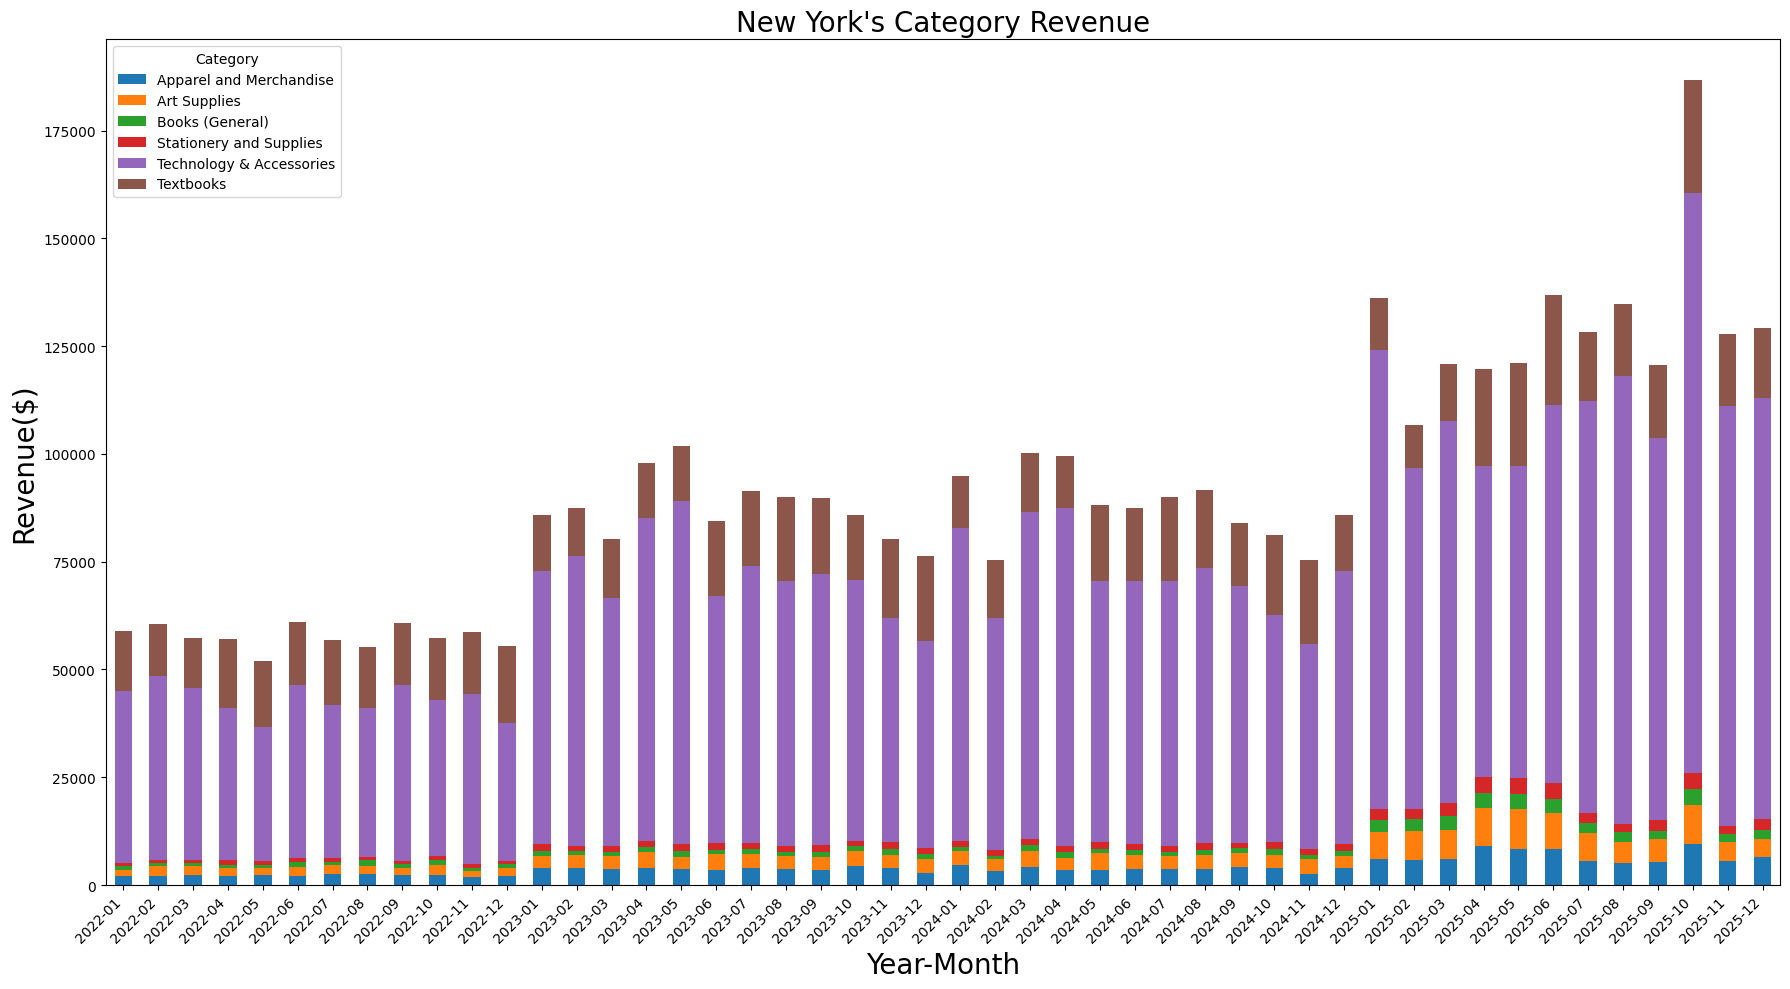

In [88]:
# Bar chart for New York's Category Revenue
ny_bars = ny_prod_revenue.pivot(index="Date", columns="Category", values="Total Revenue")
ny_bars.plot(kind="bar", stacked=True, figsize=(18,10))
plt.title("New York's Category Revenue", fontsize=20)
plt.xlabel("Year-Month", fontsize=20)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Revenue($)", fontsize=20)
plt.tight_layout()
plt.show()



**What might this tell you about the most popular products, and where could there be opportunity for growth?**

- Based of the count of transaction per category, I see that stationaries and technology has the highest transaction count compared to other categories. We can say that they are in high demand in Connecticut and New York. An opportunity of growth I can see is to focus on art supplies. Over a period of 3 years, art supplies always kept up in total transaction count and increased revenue over the years. There is constant growth in both territories.

**What is your recommendation for where to focus marketing attention in the next quarter?**

- A very important detail I would like to highlight is the performance of the stores in New York. There is a large gap of total revenue between the top 2 stores and the rest. New York and Rochester are the highest performing stores in New York with more than $600,000 in sales. The other 10 stores has 50% less in sales. I think there is a huge gap due to the population of where the store is located. An approach to get the sales higher is to promote products that are underselling like general books or textbooks. A good time to start promotion is in July. Since school starts in August, a July campaign will give more time to get supplies and a period of time to make any necessary changes. The focus should be in the New York territory. I think that the sales in Connecticut is fine, since there is no outliers or huge gaps in sales between the stores.